## Autoencoder Pipeline
Load preprocessed hypnograms, train the autoencoder, and analyze the latent space.


In [31]:
import glob
import os
import random
import re

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import umap
from sklearn.cluster import AgglomerativeClustering, HDBSCAN
from sklearn.metrics import silhouette_score, f1_score, cohen_kappa_score, classification_report
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from torch.utils.data import DataLoader, Dataset, Subset
from matplotlib.lines import Line2D
from tqdm import tqdm


## Imports
Libraries for training, clustering, optimization, and visualization.


In [32]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED) 
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def get_mode(arr):
    if len(arr) == 0:
        return 0
    vals, counts = np.unique(arr, return_counts=True)
    return vals[np.argmax(counts)]


class HypnogramDataset(Dataset):
    def __init__(
        self,
        fif_root,
        cohort_mode="sc_only",
        preprocessed_dir="preprocessed",
        target_len=1224,
        epoch_sec=30,
        min_valid_epochs=600,
    ):
        pattern = os.path.join(fif_root, "**", preprocessed_dir, "*.fif")
        all_files = sorted(glob.glob(pattern, recursive=True))

        self.files = self._filter_files(all_files, cohort_mode)

        self.target_len = target_len
        self.epoch_sec = epoch_sec
        self.cohort_mode = cohort_mode
        self.min_valid_epochs = min_valid_epochs

        self.data = []
        self.orig_lengths = []
        self.true_lengths = []
        self.cohorts = []
        self.subject_ids = []
        self.file_paths = []

        self._process_files()

    @staticmethod
    def _filter_files(files, cohort_mode):
        if cohort_mode == "sc_only":
            return [f for f in files if "sleep-cassette" in f]

        if cohort_mode == "st_only":
            return [f for f in files if "sleep-telemetry" in f]

        if cohort_mode == "both":
            return files

        return files

    @staticmethod
    def _extract_subject_id(file_path):
        basename = os.path.basename(file_path)
        match = re.match(r"(SC4\d{2}|ST7\d{2})", basename)
        return match.group(1) if match else "Unknown"

    def _process_files(self):
        for file in tqdm(self.files, desc=f"Loading {self.cohort_mode}"):
            raw = mne.io.read_raw_fif(file, preload=False, verbose="ERROR")

            total_duration = raw.times[-1]
            num_epochs = int(total_duration // self.epoch_sec)

            sequence = np.full(num_epochs, -1, dtype=np.int64)

            for annot in raw.annotations:
                start_ep = int(annot["onset"] // self.epoch_sec)
                end_ep = int((annot["onset"] + annot["duration"]) // self.epoch_sec)

                start_ep = max(0, start_ep)
                end_ep = min(num_epochs, end_ep)

                if end_ep <= start_ep:
                    continue

                try:
                    stage = int(annot["description"])
                except ValueError:
                    continue

                if stage != -1:
                    sequence[start_ep:end_ep] = stage

            valid_seq = sequence[(sequence != -1) & (sequence != 5)]

            true_len = len(valid_seq)

            seq = valid_seq[:self.target_len]
            effective_len = len(seq)

            pad_len = self.target_len - effective_len
            padded_seq = np.pad(seq, (0, pad_len), constant_values=5)

            self.data.append(padded_seq)
            self.orig_lengths.append(effective_len)
            self.true_lengths.append(true_len)
            self.cohorts.append(0 if "sleep-cassette" in file else 1)
            self.subject_ids.append(self._extract_subject_id(file))
            self.file_paths.append(file)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq = torch.tensor(self.data[idx], dtype=torch.long)
        orig_len = torch.tensor(self.orig_lengths[idx], dtype=torch.float32)
        cohort = torch.tensor(self.cohorts[idx], dtype=torch.long)

        return seq, orig_len, cohort


fif_root = os.path.join(".", "sleep-edf-database")

healthy_dataset = HypnogramDataset(
    fif_root,
    cohort_mode="sc_only",
    target_len=1024,
    min_valid_epochs=600,
)

unhealthy_dataset = HypnogramDataset(
    fif_root,
    cohort_mode="st_only",
    target_len=1024,
    min_valid_epochs=600,
)

if len(unhealthy_dataset) == 0:
    unhealthy_dataset = None


subject_ids = np.array(healthy_dataset.subject_ids)
indices = np.arange(len(healthy_dataset))

train_splitter = GroupShuffleSplit(
    n_splits=1,
    train_size=0.8,
    random_state=SEED,
)

train_indices, holdout_indices = next(
    train_splitter.split(indices, groups=subject_ids)
)

holdout_subjects = subject_ids[holdout_indices]

val_test_splitter = GroupShuffleSplit(
    n_splits=1,
    train_size=0.5,
    random_state=SEED,
)

val_rel, test_rel = next(
    val_test_splitter.split(holdout_indices, groups=holdout_subjects)
)

val_indices = holdout_indices[val_rel]
test_indices = holdout_indices[test_rel]


train_dataloader = DataLoader(
    Subset(healthy_dataset, train_indices),
    batch_size=16,
    shuffle=True,
)

val_dataloader = DataLoader(
    Subset(healthy_dataset, val_indices),
    batch_size=16,
    shuffle=False,
)

test_dataloader = DataLoader(
    Subset(healthy_dataset, test_indices),
    batch_size=16,
    shuffle=False,
)


print(f"Healthy nights loaded: {len(healthy_dataset)}")

if unhealthy_dataset is not None:
    print(f"Unhealthy nights loaded: {len(unhealthy_dataset)}")
else:
    print("No unhealthy nights loaded.")

print(f"Train nights: {len(train_indices)}")
print(f"Validation nights: {len(val_indices)}")
print(f"Test nights: {len(test_indices)}")

print(f"Train subjects: {len(set(subject_ids[train_indices]))}")
print(f"Validation subjects: {len(set(subject_ids[val_indices]))}")
print(f"Test subjects: {len(set(subject_ids[test_indices]))}")


Loading st_only: 100%|██████████| 44/44 [02:01<00:00,  2.76s/it]

Healthy nights loaded: 153
Unhealthy nights loaded: 44
Train nights: 121
Validation nights: 16
Test nights: 16
Train subjects: 62
Validation subjects: 8
Test subjects: 8


## Model Definition
Variational LSTM autoencoder with temporal downsampling and latent regularization.


In [33]:
# Variational LSTM autoencoder with temporal downsampling.
# The bottleneck predicts the latent mean and log-variance.
# KL regularization encourages a continuous latent space.

class HypnoLSTMVAE(nn.Module):
    def __init__(self, seq_len=1024, num_classes=7, embed_dim=32, hidden_dim=64, latent_dim=32):
        super().__init__()
        self.seq_len = seq_len
        
        self.embedding = nn.Embedding(num_classes, embed_dim)
        
        # Temporal downsampling.
        self.pool = nn.MaxPool1d(kernel_size=4, stride=4)
        
        # Bidirectional sequence encoder.
        self.encoder_lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.feature_dim = hidden_dim * 2 
        
        # Variational bottleneck.
        self.flat_dim = int((self.seq_len / 4) * self.feature_dim) 
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        
        # Decoder initialization.
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)
        
        # Sequence decoder.
        self.decoder_lstm = nn.LSTM(self.feature_dim, hidden_dim, batch_first=True, bidirectional=True)
        
        # Restore the original temporal resolution.
        self.upsample = nn.Upsample(scale_factor=4, mode='nearest')
        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def reparameterize(self, mu, logvar):
        """Samples z from the predicted distribution."""
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu  # Use the posterior mean during evaluation.

    def forward(self, x, orig_lens=None):
        emb = self.embedding(x) 
        emb_pooled = self.pool(emb.transpose(1, 2)).transpose(1, 2) 
        
        enc_out, _ = self.encoder_lstm(emb_pooled) 
        flat_enc = enc_out.contiguous().view(enc_out.size(0), -1) 
        
        # Estimate the latent distribution parameters.
        mu = self.fc_mu(flat_enc)
        logvar = self.fc_logvar(flat_enc)
        z = self.reparameterize(mu, logvar)
        
        # Reconstruct the sequence from the latent sample.
        dec_init = self.fc_decode(z)
        dec_in = dec_init.view(dec_init.size(0), int(self.seq_len/4), self.feature_dim) 
        dec_out, _ = self.decoder_lstm(dec_in) 
        dec_out_up = self.upsample(dec_out.transpose(1, 2)).transpose(1, 2) 
        logits = self.classifier(dec_out_up) 
        
        return logits.transpose(1, 2), z, mu, logvar

## Loss Function
Weighted Dice loss with padding-aware masking for imbalanced stage labels.


In [34]:
class WeightedDiceLoss(nn.Module):
    def __init__(self, weight=None, ignore_index=5):
        super().__init__()
        self.weight = weight
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        valid_mask = (targets != self.ignore_index)
        
        total_loss = 0.0
        weight_sum = 0.0
        
        # Restrict the Dice term to the five scored sleep stages.
        for c in range(5):
            true_c = (targets == c).float()[valid_mask]
            pred_c = probs[:, c, :][valid_mask]
            
            intersection = (pred_c * true_c).sum()
            union = pred_c.sum() + true_c.sum()
            
            epsilon = 1e-7
            dice_c = (2. * intersection + epsilon) / (union + epsilon)
            
            w = self.weight[c] if self.weight is not None else 1.0
            
            total_loss += w * (1 - dice_c)
            weight_sum += w
            
        return total_loss / (weight_sum + 1e-7)


## Model Training
Training loop for the variational autoencoder and its loss components.


Using device: cuda


Training Optimized VAE:  82%|████████▏ | 163/200 [01:04<00:14,  2.52it/s]


Early stopping triggered after epoch 164
Test Loss (Total): 0.4869 | Recon: 0.4455 | KL: 41.3670


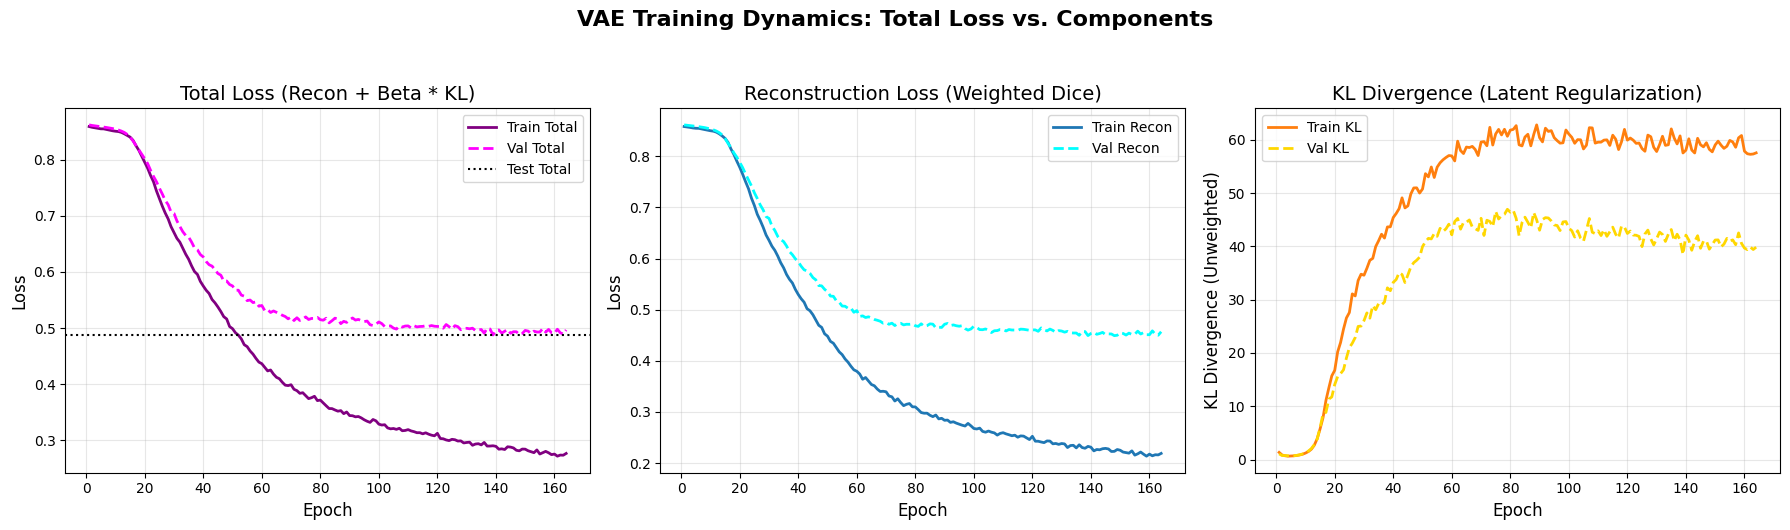

In [35]:
# Train the variational autoencoder and track each loss component.

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = HypnoLSTMVAE(
    seq_len=1024, 
    num_classes=7, 
    embed_dim=64,     
    hidden_dim=32,    
    latent_dim=64    
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=0.00015794821662802687,          
    weight_decay=9.12872140589031e-06  
)

BETA = 0.001 

manual_weights = [1.0, 2.5, 0.5, 1.0, 2.0]
class_weights = torch.tensor(manual_weights, dtype=torch.float32).to(device)
dice_criterion = WeightedDiceLoss(weight=class_weights, ignore_index=5)

def apply_masking(seq, mask_prob, mask_token=6, pad_token=5):
    mask = (torch.rand(seq.shape, device=seq.device) < mask_prob) & (seq != pad_token)
    masked_seq = seq.clone()
    masked_seq[mask] = mask_token
    return masked_seq

# Return total, reconstruction, and KL losses.
def evaluate_reconstruction_loss(dataloader):
    model.eval()
    total_loss, total_recon, total_kl = 0.0, 0.0, 0.0
    with torch.no_grad():
        for seq, orig_len, _ in dataloader:
            seq = seq.to(device)
            orig_len = orig_len.to(device)
            logits, _, mu, logvar = model(seq, orig_lens=orig_len)
            
            recon_loss = dice_criterion(logits, seq)
            kl_loss = torch.mean(-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
            loss = recon_loss + (BETA * kl_loss) 
            
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            
    n = max(1, len(dataloader))
    return total_loss / n, total_recon / n, total_kl / n


num_epochs = int(os.environ.get("AUTOENCODER_NUM_EPOCHS", 200))

# Store the total, reconstruction, and KL loss histories.
train_losses, val_losses = [], []
train_recon_losses, val_recon_losses = [], []
train_kl_losses, val_kl_losses = [], []

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in tqdm(range(num_epochs), desc="Training Optimized VAE"):
    model.train()
    total_train_loss, total_train_recon, total_train_kl = 0.0, 0.0, 0.0

    for seq, orig_len, _ in train_dataloader:
        seq = seq.to(device)
        orig_len = orig_len.to(device)
        
        masked_seq = apply_masking(seq, mask_prob=0.12002313675587827) 
        
        optimizer.zero_grad()
        logits, z, mu, logvar = model(masked_seq, orig_lens=orig_len)
        
        recon_loss = dice_criterion(logits, seq)
        kl_loss = torch.mean(-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
        loss = recon_loss + (BETA * kl_loss)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Accumulate batch-wise loss totals.
        total_train_loss += loss.item()
        total_train_recon += recon_loss.item()
        total_train_kl += kl_loss.item()

    # Store epoch-level averages.
    n_batches = len(train_dataloader)
    train_losses.append(total_train_loss / n_batches)
    train_recon_losses.append(total_train_recon / n_batches)
    train_kl_losses.append(total_train_kl / n_batches)

    # Evaluate on the validation split.
    avg_val_loss, avg_val_recon, avg_val_kl = evaluate_reconstruction_loss(val_dataloader)
    val_losses.append(avg_val_loss)
    val_recon_losses.append(avg_val_recon)
    val_kl_losses.append(avg_val_kl)

    # Apply early stopping.
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= 25:
        print(f"\nEarly stopping triggered after epoch {epoch + 1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

test_loss, test_recon, test_kl = evaluate_reconstruction_loss(test_dataloader)
print(f"Test Loss (Total): {test_loss:.4f} | Recon: {test_recon:.4f} | KL: {test_kl:.4f}")

# Plot total, reconstruction, and KL losses.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VAE Training Dynamics: Total Loss vs. Components', fontsize=16, fontweight='bold', y=1.05)

# Panel 1: total loss.
axes[0].plot(range(1, len(train_losses) + 1), train_losses, label='Train Total', color='purple', linewidth=2)
axes[0].plot(range(1, len(val_losses) + 1), val_losses, label='Val Total', color='magenta', linestyle='--', linewidth=2)
axes[0].axhline(test_loss, color='black', linestyle=':', label='Test Total')
axes[0].set_title('Total Loss (Recon + Beta * KL)', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Panel 2: reconstruction loss.
axes[1].plot(range(1, len(train_recon_losses) + 1), train_recon_losses, label='Train Recon', color='tab:blue', linewidth=2)
axes[1].plot(range(1, len(val_recon_losses) + 1), val_recon_losses, label='Val Recon', color='cyan', linestyle='--', linewidth=2)
axes[1].set_title('Reconstruction Loss (Weighted Dice)', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Panel 3: KL divergence.
axes[2].plot(range(1, len(train_kl_losses) + 1), train_kl_losses, label='Train KL', color='tab:orange', linewidth=2)
axes[2].plot(range(1, len(val_kl_losses) + 1), val_kl_losses, label='Val KL', color='gold', linestyle='--', linewidth=2)
axes[2].set_title('KL Divergence (Latent Regularization)', fontsize=14)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('KL Divergence (Unweighted)', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

## Evaluation Metrics


In [36]:
def evaluate_metrics(model, dataloader, device, pad_token=5):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for seq, orig_len, _ in dataloader:
            seq = seq.to(device)
            orig_len = orig_len.to(device)
            
            logits, _, _, _ = model(seq, orig_lens=orig_len)
            preds = torch.argmax(logits, dim=1).view(-1).cpu().numpy()
            targets = seq.view(-1).cpu().numpy()
            
            valid_indices = targets != pad_token
            all_preds.extend(preds[valid_indices])
            all_targets.extend(targets[valid_indices])
            
    macro_f1 = f1_score(all_targets, all_preds, average='macro', labels=[0,1,2,3,4])
    weighted_f1 = f1_score(all_targets, all_preds, average='weighted', labels=[0,1,2,3,4])
    kappa = cohen_kappa_score(all_targets, all_preds)
    
    print(f"Macro F1-Score:    {macro_f1:.4f}")
    print(f"Weighted F1-Score: {weighted_f1:.4f}")
    print(f"Cohen's Kappa:     {kappa:.4f}")
    
    target_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
    print("\nDetailed Classification Report:")
    print(classification_report(all_targets, all_preds, labels=[0, 1, 2, 3, 4], target_names=target_names, zero_division=0))
    
    return macro_f1, kappa

test_f1, test_kappa = evaluate_metrics(model, test_dataloader, device)


Macro F1-Score:    0.6156
Weighted F1-Score: 0.6610
Cohen's Kappa:     0.5302

Detailed Classification Report:
              precision    recall  f1-score   support

        Wake       0.77      0.62      0.69      2592
          N1       0.48      0.29      0.36      2232
          N2       0.66      0.86      0.75      6883
          N3       0.72      0.45      0.55      1549
         REM       0.73      0.72      0.72      2495

    accuracy                           0.68     15751
   macro avg       0.67      0.59      0.62     15751
weighted avg       0.67      0.68      0.66     15751



## Sequence Inspection


Patient 0 Predicted Epochs -> Wake: 68, N1: 52, N2: 692, N3: 0, REM: 212
Patient 1 Predicted Epochs -> Wake: 68, N1: 92, N2: 652, N3: 20, REM: 192
Patient 2 Predicted Epochs -> Wake: 55, N1: 28, N2: 520, N3: 72, REM: 316


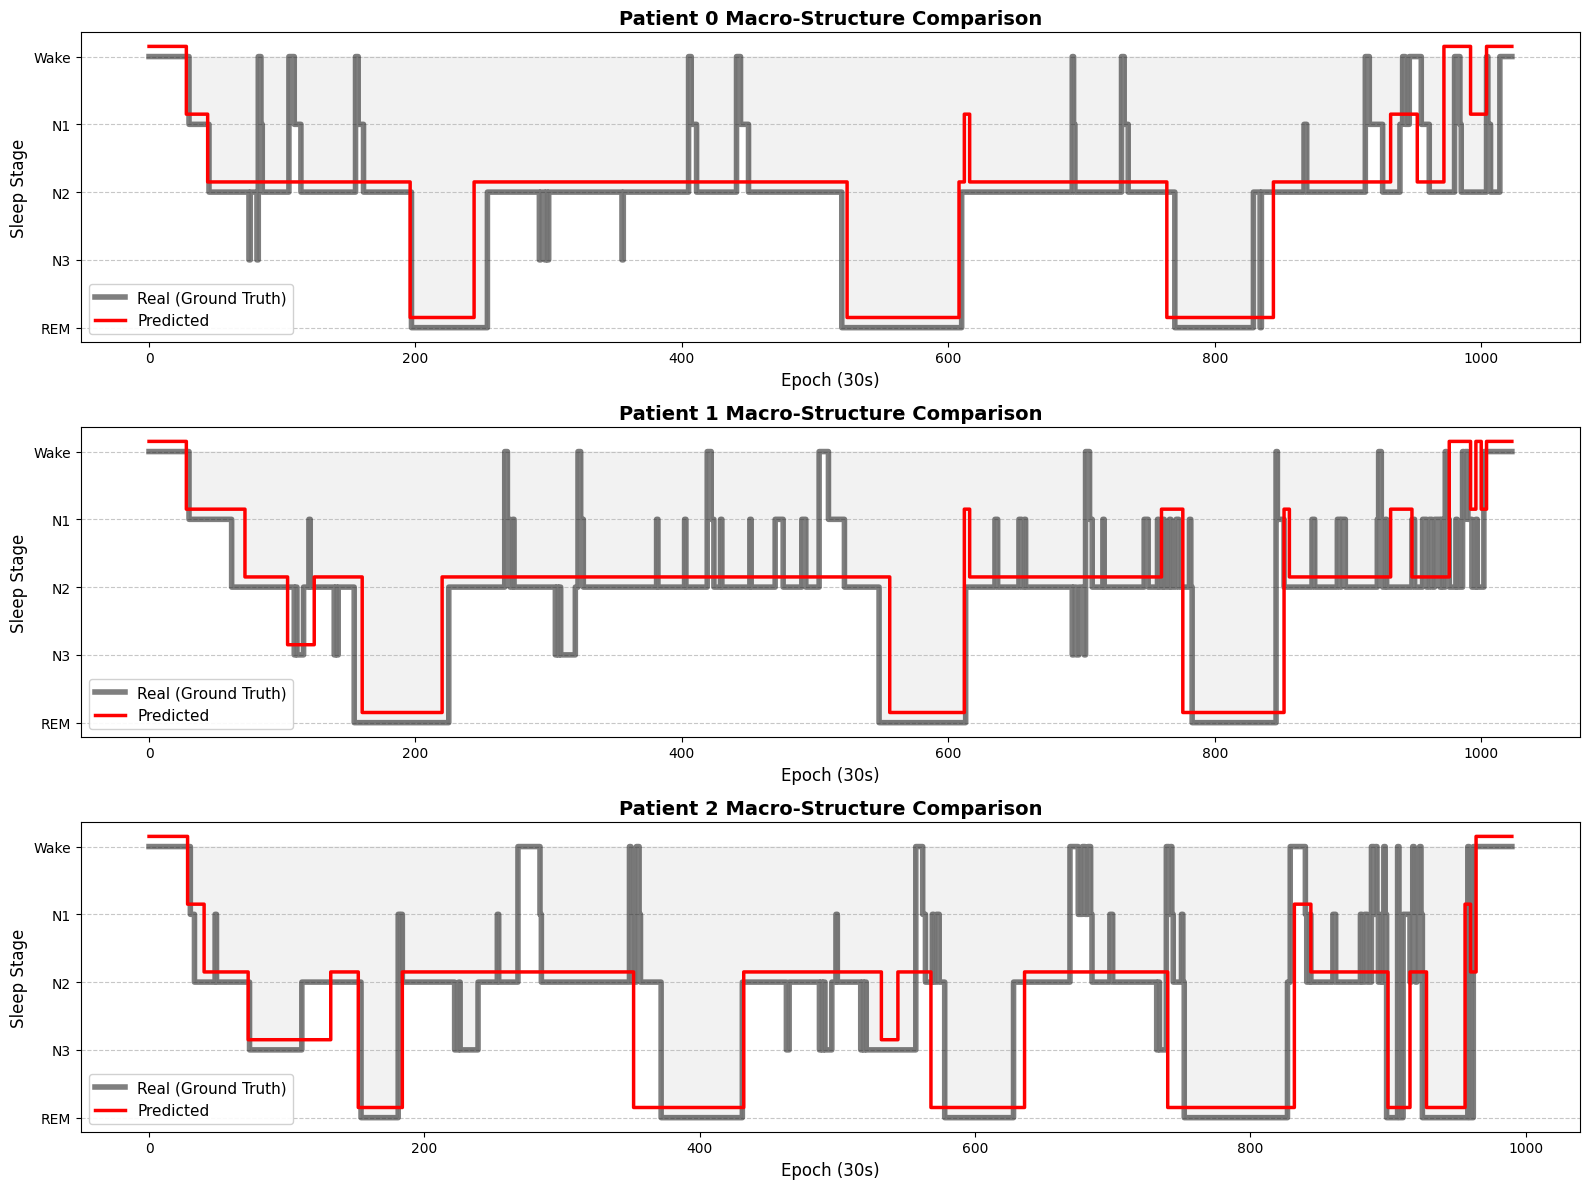

In [37]:
model.eval()

# Inspect one validation batch.
seq, orig_len, _ = next(iter(val_dataloader))
seq = seq.to(device)
orig_len = orig_len.to(device)

with torch.no_grad():
    logits, _, _, _= model(seq, orig_lens=orig_len)
    preds = logits.argmax(dim=1).cpu().numpy()
    targets = seq.cpu().numpy()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for i in range(3):
    true_seq = targets[i]
    pred_seq = preds[i]

    valid_len = int(orig_len[i].item())
    true_seq = true_seq[:valid_len]
    pred_seq = pred_seq[:valid_len]
    
    unique, counts = np.unique(pred_seq, return_counts=True)
    stage_counts = dict(zip(unique, counts))
    print(f"Patient {i} Predicted Epochs -> Wake: {stage_counts.get(0, 0)}, N1: {stage_counts.get(1, 0)}, N2: {stage_counts.get(2, 0)}, N3: {stage_counts.get(3, 0)}, REM: {stage_counts.get(4, 0)}")

    x_axis = np.arange(valid_len)

    # Reference sequence.
    axes[i].plot(x_axis, true_seq, label="Real (Ground Truth)", color='black', alpha=0.5, linewidth=4, drawstyle='steps-post')
    axes[i].fill_between(x_axis, true_seq, step='post', color='black', alpha=0.05)

    # Predicted sequence, offset slightly for visual separation.
    offset_pred = pred_seq - 0.15 
    axes[i].plot(x_axis, offset_pred, label="Predicted", color='red', linewidth=2.5, drawstyle='steps-post')

    axes[i].set_yticks([0, 1, 2, 3, 4])
    axes[i].set_yticklabels(['Wake', 'N1', 'N2', 'N3', 'REM'])
    axes[i].invert_yaxis()
    
    axes[i].set_title(f"Patient {i} Macro-Structure Comparison", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Epoch (30s)", fontsize=12)
    axes[i].set_ylabel("Sleep Stage", fontsize=12)
    
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].legend(loc="lower left", fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()


## Latent Space Analysis


In [38]:
# Extract latent means and project them into two dimensions.
# Use the posterior mean for clustering and UMAP projection.

def refresh_latent_analysis(n_clusters=3):
    def extract_embeddings(source_dataset, desc):
        dataloader = DataLoader(source_dataset, batch_size=32, shuffle=False)
        embeddings = []
        cohorts = []

        model.eval()
        with torch.no_grad():
            for seq, orig_len, cohort in tqdm(dataloader, desc=desc, leave=False):
                seq = seq.to(device)
                orig_len = orig_len.to(device)
                
                # Use the posterior mean for stable clustering.
                _, _, mu, _ = model(seq, orig_lens=orig_len)
                embeddings.append(mu.cpu().numpy())
                cohorts.append(cohort.numpy())
                
        if not embeddings:
            return np.empty((0, model.latent_dim)), np.empty(0) 
        return np.vstack(embeddings), np.concatenate(cohorts)

    # Extract healthy embeddings.
    healthy_embeddings, healthy_cohorts = extract_embeddings(
        healthy_dataset,
        desc="Extracting healthy embeddings",
    )

    if healthy_embeddings.shape[0] < n_clusters:
        raise ValueError(
            f"Need at least {n_clusters} healthy nights for clustering, got {healthy_embeddings.shape[0]}."
        )

    # Fit a provisional agglomerative clustering model.
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    healthy_cluster_labels = clusterer.fit_predict(healthy_embeddings)

    healthy_silhouette = np.nan
    if len(np.unique(healthy_cluster_labels)) > 1:
        healthy_silhouette = silhouette_score(healthy_embeddings, healthy_cluster_labels)

    # Apply the selected UMAP configuration.
    reducer = umap.UMAP(
        n_components=2, 
        n_neighbors=42, 
        min_dist=0.006285531607433633, 
        spread=0.5069495242716742,
        metric="cosine", 
        random_state=SEED
    )
    healthy_umap = reducer.fit_transform(healthy_embeddings)

    # Project the telemetry cohort into the learned UMAP space.
    if unhealthy_dataset is not None and len(unhealthy_dataset) > 0:
        unhealthy_embeddings, unhealthy_cohorts = extract_embeddings(
            unhealthy_dataset,
            desc="Projecting unhealthy embeddings",
        )
        unhealthy_umap = reducer.transform(unhealthy_embeddings)
    else:
        unhealthy_embeddings = np.empty((0, healthy_embeddings.shape[1]), dtype=np.float32)
        unhealthy_umap = np.empty((0, 2), dtype=np.float32)

    return {
        "healthy_features": healthy_embeddings,
        "healthy_cluster_labels": healthy_cluster_labels,
        "healthy_silhouette": healthy_silhouette,
        "healthy_umap": healthy_umap,
        "unhealthy_features": unhealthy_embeddings,
        "unhealthy_umap": unhealthy_umap,
    }

# Store the results in a dictionary.
latent_analysis = refresh_latent_analysis()

# Extract the projected coordinates from the result dictionary.
healthy_umap = latent_analysis["healthy_umap"]
unhealthy_umap = latent_analysis["unhealthy_umap"]

Extracting healthy embeddings:   0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\Micae\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [39]:
from sklearn.preprocessing import normalize

def refresh_latent_analysis_optimized():
    def extract_raw_features(source_dataset, desc):
        dataloader = DataLoader(source_dataset, batch_size=32, shuffle=False)
        embeddings, cohorts = [], []
        model.eval()
        with torch.no_grad():
            for seq, orig_len, cohort in tqdm(dataloader, desc=desc, leave=False):
                seq = seq.to(device)
                orig_len = orig_len.to(device)
                _, _, mu, _ = model(seq, orig_lens=orig_len)
                embeddings.append(mu.cpu().numpy())
                cohorts.append(cohort.numpy())
        if not embeddings:
            return np.empty((0, model.latent_dim)), np.empty(0)
        return np.vstack(embeddings), np.concatenate(cohorts)

    # Extract latent features.
    healthy_features, healthy_cohorts = extract_raw_features(healthy_dataset, "Extracting Healthy")
    if unhealthy_dataset is not None and len(unhealthy_dataset) > 0:
        unhealthy_features, unhealthy_cohorts = extract_raw_features(unhealthy_dataset, "Extracting Telemetry")
    else:
        unhealthy_features = np.empty((0, healthy_features.shape[1]))

    # Apply L2 normalization instead of standard scaling.
    # This matches the cosine geometry used by UMAP and reduces
    # cohort-specific scaling differences between SC and ST.
    healthy_features_scaled = normalize(healthy_features, norm='l2', axis=1)
    
    if len(unhealthy_features) > 0:
        unhealthy_features_scaled = normalize(unhealthy_features, norm='l2', axis=1)
    else:
        unhealthy_features_scaled = np.empty((0, healthy_features.shape[1]))

    # Fit UMAP on the healthy cohort.
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=42,
        min_dist=0.006285531607433633,
        spread=0.5069495242716742,
        metric="cosine",  # Match the normalized feature geometry.
        random_state=SEED
    )
    healthy_umap = reducer.fit_transform(healthy_features_scaled)
    unhealthy_umap = reducer.transform(unhealthy_features_scaled) if len(unhealthy_features_scaled) > 0 else np.empty((0, 2))

    # Fit HDBSCAN on the healthy embedding map.
    clusterer = HDBSCAN(
        min_cluster_size=28,
        min_samples=2,
        cluster_selection_method="leaf"
    )
    healthy_cluster_labels = clusterer.fit_predict(healthy_umap)
    valid_mask = healthy_cluster_labels != -1

    if len(np.unique(healthy_cluster_labels[valid_mask])) > 1:
        healthy_silhouette = silhouette_score(healthy_umap[valid_mask], healthy_cluster_labels[valid_mask])
    else:
        healthy_silhouette = np.nan

    # Assign telemetry labels with an out-of-distribution check.
    if len(unhealthy_features) > 0 and np.sum(valid_mask) >= 5:
        # Predict the nearest healthy cluster label.
        knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
        knn.fit(healthy_umap[valid_mask], healthy_cluster_labels[valid_mask])
        unhealthy_assigned_labels = knn.predict(unhealthy_umap)

        # Use a less restrictive out-of-distribution threshold.
        # This allows telemetry samples to deviate further from healthy centers
        # before being labeled as noise.
        nn = NearestNeighbors(n_neighbors=5)
        nn.fit(healthy_umap[valid_mask])
        healthy_distances, _ = nn.kneighbors(healthy_umap[valid_mask])
        unhealthy_distances, _ = nn.kneighbors(unhealthy_umap)

        # Scale the 99th-percentile healthy distance by a tolerance factor.
        base_threshold = np.percentile(healthy_distances[:, -1], 99)
        ood_threshold = base_threshold * 3.0 


        
    else:
        unhealthy_assigned_labels = np.full(len(unhealthy_umap), -1, dtype=int)
        ood_threshold = np.nan
        telemetry_outside_reference = np.full(len(unhealthy_umap), True, dtype=bool)

    return {
        "healthy_features": healthy_features,
        "healthy_cluster_labels": healthy_cluster_labels,
        "healthy_silhouette": healthy_silhouette,
        "healthy_umap": healthy_umap,
        "unhealthy_features": unhealthy_features,
        "unhealthy_umap": unhealthy_umap,
        "unhealthy_assigned_labels": unhealthy_assigned_labels,
        "ood_threshold": ood_threshold,
        "telemetry_outside_reference": telemetry_outside_reference,
    }

In [40]:
# Extract latent means and project them into two dimensions.
# Use the posterior mean and the Optuna-selected manifold settings.
# Include additional clinical summary metrics for interpretation.

from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
import pandas as pd

def compute_metrics_from_loaded_dataset(source_dataset):
    rows = []
    for seq, orig_len in zip(source_dataset.data, source_dataset.orig_lengths):
        seq = np.asarray(seq)
        valid_seq = seq[(seq != -1) & (seq != 5)]
        used_len = len(valid_seq)

        if used_len > 0:
            perc_wake = np.mean(valid_seq == 0) * 100
            perc_light = np.mean((valid_seq == 1) | (valid_seq == 2)) * 100
            perc_deep = np.mean(valid_seq == 3) * 100
            perc_rem = np.mean(valid_seq == 4) * 100
            
            # Additional clinical metrics.
            # Sleep efficiency: non-wake time divided by total valid time.
            sleep_efficiency = (1.0 - np.mean(valid_seq == 0)) * 100
            
            # Fragmentation index: number of stage transitions per hour.
            transitions = np.sum(np.diff(valid_seq) != 0)
            hours_in_bed = used_len * (source_dataset.epoch_sec / 3600.0)
            fragmentation_index = transitions / hours_in_bed if hours_in_bed > 0 else 0
            
        else:
            perc_wake, perc_light, perc_deep, perc_rem = 0.0, 0.0, 0.0, 0.0
            sleep_efficiency, fragmentation_index = 0.0, 0.0

        rows.append({
            "% Wake": perc_wake,
            "% Light (N1+N2)": perc_light,
            "% Deep (N3)": perc_deep,
            "% REM": perc_rem,
            "Sleep Efficiency (%)": sleep_efficiency,
            "Fragmentation (Trans/Hr)": fragmentation_index,
            "Night_Length": orig_len,
            "Used_Epochs_For_Percentages": used_len,
        })

    return pd.DataFrame(rows)



def refresh_latent_analysis_optimized():
    def extract_raw_features(source_dataset, desc):
        dataloader = DataLoader(source_dataset, batch_size=32, shuffle=False)
        embeddings = []
        cohorts = []

        model.eval()
        with torch.no_grad():
            for seq, orig_len, cohort in tqdm(dataloader, desc=desc, leave=False):
                seq = seq.to(device)
                orig_len = orig_len.to(device)

                # Use the posterior mean of the VAE distribution.
                _, _, mu, _ = model(seq, orig_lens=orig_len)

                embeddings.append(mu.cpu().numpy())
                cohorts.append(cohort.numpy())

        if not embeddings:
            return np.empty((0, model.latent_dim)), np.empty(0)

        return np.vstack(embeddings), np.concatenate(cohorts)

    # Extract features from the healthy and telemetry cohorts.
    healthy_features, healthy_cohorts = extract_raw_features(
        healthy_dataset,
        "Extracting Healthy"
    )

    if unhealthy_dataset is not None and len(unhealthy_dataset) > 0:
        unhealthy_features, unhealthy_cohorts = extract_raw_features(
            unhealthy_dataset,
            "Extracting Telemetry"
        )
    else:
        unhealthy_features = np.empty((0, healthy_features.shape[1]))

    # Scale the healthy cohort as the reference feature space.
    # Healthy subjects define the reference scaling.
    # Fit the scaler on healthy subjects only.
    # Apply the same transform to telemetry subjects.
    scaler = StandardScaler()

    healthy_features_scaled = scaler.fit_transform(healthy_features)

    if len(unhealthy_features) > 0:
        unhealthy_features_scaled = scaler.transform(unhealthy_features)
    else:
        unhealthy_features_scaled = np.empty((0, healthy_features.shape[1]))

    # Fit UMAP on the healthy reference cohort.
    # The healthy cohort defines the reference topology.
    # Telemetry subjects are projected into that fixed topology.
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=42,
        min_dist=0.006285531607433633,
        spread=0.5069495242716742,
        metric="cosine",
        random_state=SEED
    )

    healthy_umap = reducer.fit_transform(healthy_features_scaled)

    if len(unhealthy_features_scaled) > 0:
        unhealthy_umap = reducer.transform(unhealthy_features_scaled)
    else:
        unhealthy_umap = np.empty((0, 2))

    # Fit HDBSCAN on the healthy UMAP projection.
    # Derive phenotype clusters exclusively from healthy subjects.
    clusterer = HDBSCAN(
    min_cluster_size=10,
    min_samples=7,
    cluster_selection_method="leaf"
)

    healthy_cluster_labels = clusterer.fit_predict(healthy_umap)

    valid_mask = healthy_cluster_labels != -1

    if len(np.unique(healthy_cluster_labels[valid_mask])) > 1:
        healthy_silhouette = silhouette_score(
            healthy_umap[valid_mask],
            healthy_cluster_labels[valid_mask]
        )
    else:
        healthy_silhouette = np.nan

    # Assign telemetry labels with an out-of-distribution check.
    # KNN assigns a telemetry subject to a healthy cluster only if
    # the projection remains sufficiently close to the healthy reference space.
    # Otherwise the sample is labeled as noise (-1).

    if len(unhealthy_features) > 0 and np.sum(valid_mask) >= 5:
            knn = KNeighborsClassifier(n_neighbors=5)
            knn.fit(
                healthy_umap[valid_mask],
                healthy_cluster_labels[valid_mask]
            )

            unhealthy_assigned_labels = knn.predict(unhealthy_umap)

            # Measure distance to the healthy reference space.
            nn = NearestNeighbors(n_neighbors=5)
            nn.fit(healthy_umap[valid_mask])

            healthy_distances, _ = nn.kneighbors(healthy_umap[valid_mask])
            unhealthy_distances, _ = nn.kneighbors(unhealthy_umap)

            # Use a more permissive out-of-distribution threshold.
            # Start from the 99th percentile of healthy distances and apply a tolerance factor.
            # This prevents conservative rejection of plausible telemetry assignments.
            base_threshold = np.percentile(healthy_distances[:, -1], 99)
            ood_threshold = base_threshold * 5.0 

            # Mark clearly outlying telemetry samples as noise (-1).
            telemetry_outside_reference = unhealthy_distances[:, -1] > ood_threshold
            unhealthy_assigned_labels[telemetry_outside_reference] = -1

    else:
        unhealthy_assigned_labels = np.full(len(unhealthy_umap), -1, dtype=int)
        ood_threshold = np.nan
        telemetry_outside_reference = np.full(len(unhealthy_umap), True, dtype=bool)

    return {
        "healthy_features": healthy_features,
        "healthy_cluster_labels": healthy_cluster_labels,
        "healthy_silhouette": healthy_silhouette,
        "healthy_umap": healthy_umap,

        "unhealthy_features": unhealthy_features,
        "unhealthy_umap": unhealthy_umap,
        "unhealthy_assigned_labels": unhealthy_assigned_labels,

        "ood_threshold": ood_threshold,
        "telemetry_outside_reference": telemetry_outside_reference,
    }


# Run the analysis.
latent_analysis = refresh_latent_analysis_optimized()

# Extract the returned arrays.
healthy_cluster_labels = latent_analysis["healthy_cluster_labels"]
healthy_umap = latent_analysis["healthy_umap"]

unhealthy_umap = latent_analysis["unhealthy_umap"]
unhealthy_assigned_labels = latent_analysis["unhealthy_assigned_labels"]

ood_threshold = latent_analysis["ood_threshold"]
telemetry_outside_reference = latent_analysis["telemetry_outside_reference"]

# Prepare the dashboard dataframe.
df_healthy_metrics = compute_metrics_from_loaded_dataset(healthy_dataset)
df_healthy_metrics["Cluster_HDBSCAN"] = healthy_cluster_labels
df_healthy_metrics["Cohort"] = "Healthy (SC)"

print(f"\n✅ Clustering abgeschlossen!")
print(f"Gefundene Phänotypen ohne Rauschen: {len(np.unique(healthy_cluster_labels[healthy_cluster_labels != -1]))}")
print(f"Healthy Rausch-Punkte: {np.sum(healthy_cluster_labels == -1)}")

if len(unhealthy_assigned_labels) > 0:
    print(
        f"Telemetry außerhalb Healthy-Referenzraum: "
        f"{np.sum(unhealthy_assigned_labels == -1)} / {len(unhealthy_assigned_labels)}"
    )

c:\Users\Micae\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



✅ Clustering abgeschlossen!
Gefundene Phänotypen ohne Rauschen: 4
Healthy Rausch-Punkte: 72
Telemetry außerhalb Healthy-Referenzraum: 0 / 44


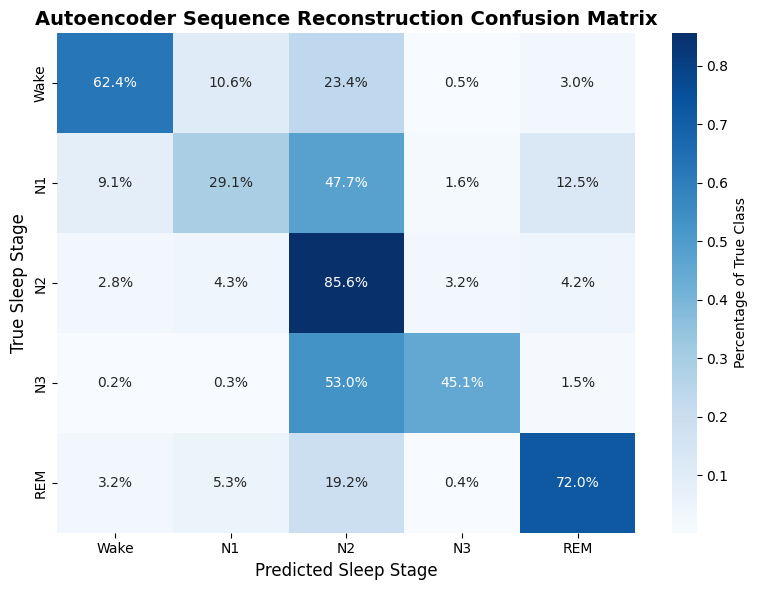

In [41]:
# Confusion matrix analysis.
# Summarize test-set stage confusions by normalized row percentages.

from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, dataloader, device, pad_token=5):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for seq, orig_len, _ in dataloader:
            seq = seq.to(device)
            orig_len = orig_len.to(device)
            
            logits, _, _, _ = model(seq, orig_lens=orig_len)
            preds = torch.argmax(logits, dim=1).view(-1).cpu().numpy()
            targets = seq.view(-1).cpu().numpy()
            
            valid_indices = targets != pad_token
            all_preds.extend(preds[valid_indices])
            all_targets.extend(targets[valid_indices])
            
    cm = confusion_matrix(all_targets, all_preds, labels=[0, 1, 2, 3, 4])
    
    # Normalize each row to show per-class percentages.
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(8, 6))
    target_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
    sns.heatmap(cm_normalized, annot=True, fmt=".1%", cmap="Blues", 
                xticklabels=target_names, yticklabels=target_names,
                cbar_kws={'label': 'Percentage of True Class'})
    
    plt.title("Autoencoder Sequence Reconstruction Confusion Matrix", fontsize=14, fontweight='bold')
    plt.ylabel('True Sleep Stage', fontsize=12)
    plt.xlabel('Predicted Sleep Stage', fontsize=12)
    plt.tight_layout()
    plt.show()

# Render the confusion matrix.
plot_confusion_matrix(model, test_dataloader, device)

## Phenotype Dashboard


C:\Users\Micae\AppData\Local\Temp\ipykernel_2016\3370835728.py:142: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(["Wake", "Light", "Deep", "REM"])
C:\Users\Micae\AppData\Local\Temp\ipykernel_2016\3370835728.py:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(["Efficiency (%)", "Frag. (Trans/Hr)"])


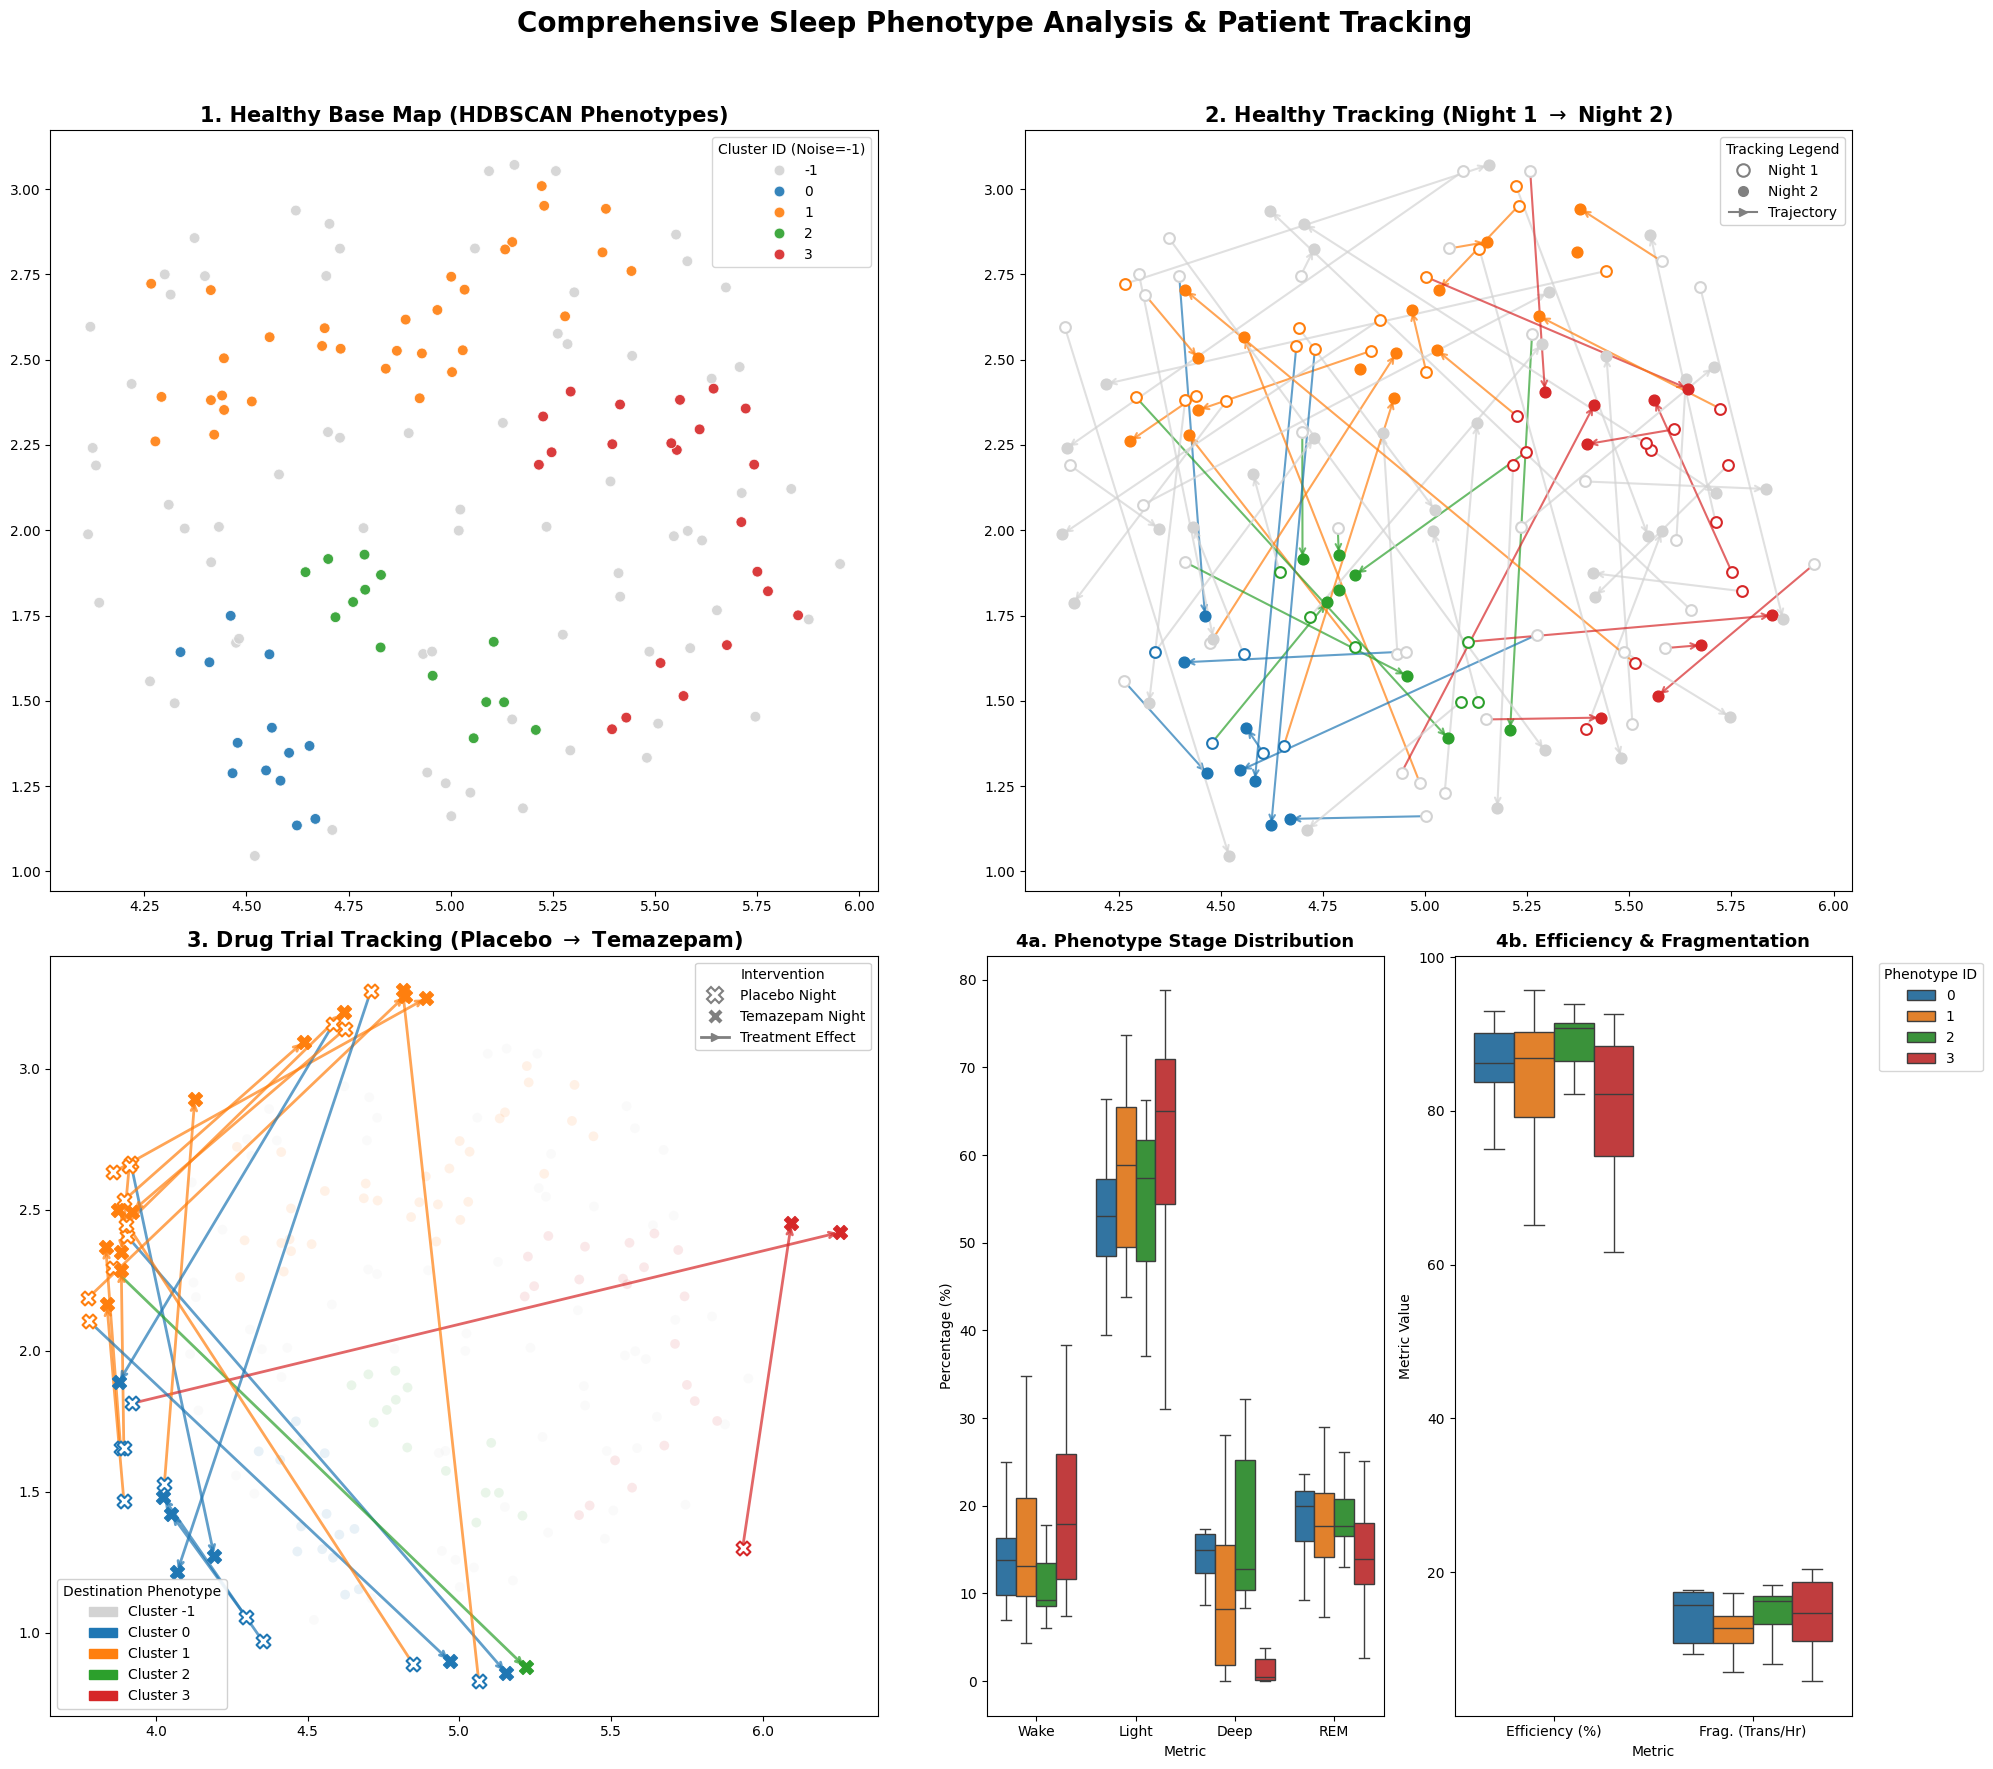

c:\Users\Micae\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


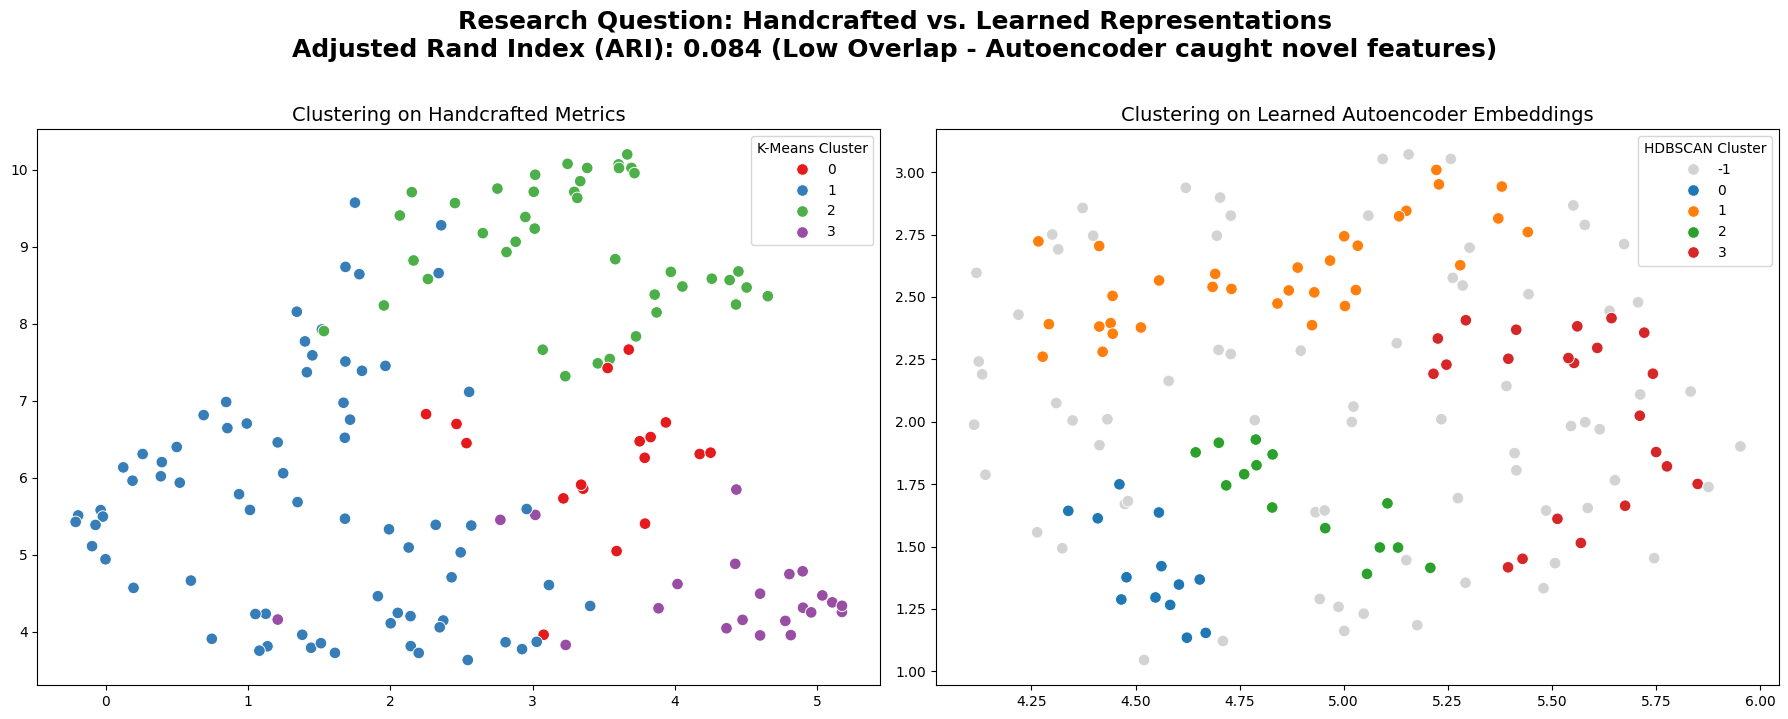

In [42]:
# Phenotype dashboard and clustering comparison.
# Combine longitudinal tracking with a comparison to handcrafted features.

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler

# Reuse the existing temazepam index map, subject arrays, and color palette.
temazepam_idx_map = {
    "ST701": 1, "ST702": 0, "ST704": 1, "ST705": 0,
    "ST706": 1, "ST707": 1, "ST708": 0, "ST709": 0,
    "ST710": 1, "ST711": 0, "ST712": 1, "ST713": 0,
    "ST714": 1, "ST715": 1, "ST716": 0, "ST717": 1,
    "ST718": 0, "ST719": 0, "ST720": 1, "ST721": 0,
    "ST722": 1, "ST724": 1
}

healthy_subj = np.array(healthy_dataset.subject_ids)
unhealthy_subj = np.array(unhealthy_dataset.subject_ids) if unhealthy_dataset is not None else np.array([])

labels_hdbscan = healthy_cluster_labels
unhealthy_assigned_hdbscan = unhealthy_assigned_labels

unique_hdb_labels = np.unique(labels_hdbscan)
hdb_palette = {}
color_idx = 0
for label in unique_hdb_labels:
    if label == -1:
        hdb_palette[label] = "lightgrey"
    else:
        hdb_palette[label] = sns.color_palette("tab10")[color_idx % 10]
        color_idx += 1

# Prepare plotting data.
df_plot_hdbscan_clean = df_healthy_metrics[df_healthy_metrics["Cluster_HDBSCAN"] != -1]

# Stage-distribution summary.
df_melt_percentages = df_plot_hdbscan_clean.melt(
    id_vars=["Cluster_HDBSCAN"], 
    value_vars=["% Wake", "% Light (N1+N2)", "% Deep (N3)", "% REM"], 
    var_name="Metric", value_name="Value"
)

# Derived clinical metrics.
df_melt_advanced = df_plot_hdbscan_clean.melt(
    id_vars=["Cluster_HDBSCAN"], 
    value_vars=["Sleep Efficiency (%)", "Fragmentation (Trans/Hr)"], 
    var_name="Metric", value_name="Value"
)


# Main dashboard.
# Increase the figure size to accommodate both clinical panels.
fig = plt.figure(figsize=(20, 18))
fig.suptitle("Comprehensive Sleep Phenotype Analysis & Patient Tracking", fontsize=20, fontweight='bold', y=0.98)

# Allocate axes for the dashboard panels.
ax1 = plt.subplot(2, 2, 1)  # Baseline map
ax2 = plt.subplot(2, 2, 2)  # Healthy trajectories
ax3 = plt.subplot(2, 2, 3)  # Placebo-temazepam trajectories
ax4 = plt.subplot(2, 4, 7)  # Stage distribution
ax5 = plt.subplot(2, 4, 8)  # Derived metrics

# Panel 1: baseline embedding map.
sns.scatterplot(x=healthy_umap[:, 0], y=healthy_umap[:, 1], hue=labels_hdbscan, palette=hdb_palette, s=60, alpha=0.9, ax=ax1)
ax1.set_title("1. Healthy Base Map (HDBSCAN Phenotypes)", fontsize=15, fontweight='bold')
ax1.legend(title="Cluster ID (Noise=-1)", loc='upper right')

# Panel 2: within-subject trajectories in the healthy cohort.
sns.scatterplot(x=healthy_umap[:, 0], y=healthy_umap[:, 1], hue=labels_hdbscan, palette=hdb_palette, s=50, alpha=0.10, ax=ax2, legend=False)
for subj in np.unique(healthy_subj):
    idx = np.where(healthy_subj == subj)[0]
    pts = healthy_umap[idx]
    
    if len(pts) > 1:
        # Use source and destination colors for each trajectory.
        source_color = hdb_palette[labels_hdbscan[idx[0]]]
        target_color = hdb_palette[labels_hdbscan[idx[-1]]]
        
        for i in range(len(pts)-1):
            ax2.annotate('', xy=(pts[i+1, 0], pts[i+1, 1]), xytext=(pts[i, 0], pts[i, 1]), arrowprops=dict(arrowstyle="->", color=target_color, lw=1.5, alpha=0.7))
        
        # Night 1 marker.
        ax2.scatter(pts[0, 0], pts[0, 1], facecolors='white', edgecolors=source_color, s=60, zorder=4, linewidths=1.5) 
        # Night 2 marker.
        ax2.scatter(pts[-1, 0], pts[-1, 1], facecolors=target_color, edgecolors=target_color, s=60, zorder=4) 
    elif len(pts) == 1:
        single_color = hdb_palette[labels_hdbscan[idx[0]]]
        ax2.scatter(pts[0, 0], pts[0, 1], facecolors=single_color, edgecolors=single_color, s=60, zorder=4)

ax2.set_title("2. Healthy Tracking (Night 1 $\\rightarrow$ Night 2)", fontsize=15, fontweight='bold')

legend_elements_2 = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='w', markeredgecolor='gray', markersize=9, markeredgewidth=1.5, label='Night 1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=9, label='Night 2'),
    Line2D([0], [0], color='gray', lw=1.5, marker='>', markersize=6, label='Trajectory')
]
ax2.legend(handles=legend_elements_2, loc='upper right', title="Tracking Legend", framealpha=0.9)

# Panel 3: placebo-to-temazepam trajectories.
sns.scatterplot(x=healthy_umap[:, 0], y=healthy_umap[:, 1], hue=labels_hdbscan, palette=hdb_palette, s=50, alpha=0.10, ax=ax3, legend=False)
if len(unhealthy_umap) > 0 and len(unhealthy_subj) > 0:
    for subj in np.unique(unhealthy_subj):
        idx = np.where(unhealthy_subj == subj)[0]
        pts = unhealthy_umap[idx]
        if len(pts) == 2 and subj in temazepam_idx_map:
            tem_idx = temazepam_idx_map[subj]
            pla_idx = 1 - tem_idx 
            
            # Use source and destination colors for each treatment pair.
            source_color = hdb_palette[unhealthy_assigned_hdbscan[idx[pla_idx]]]
            target_color = hdb_palette[unhealthy_assigned_hdbscan[idx[tem_idx]]]
            
            ax3.annotate('', xy=(pts[tem_idx][0], pts[tem_idx][1]), xytext=(pts[pla_idx][0], pts[pla_idx][1]), arrowprops=dict(arrowstyle="->", color=target_color, lw=2.0, alpha=0.7))
            
            # Placebo marker.
            ax3.scatter(pts[pla_idx][0], pts[pla_idx][1], facecolors='white', edgecolors=source_color, marker='X', s=100, linewidths=1.5, zorder=4) 
            # Temazepam marker.
            ax3.scatter(pts[tem_idx][0], pts[tem_idx][1], facecolors=target_color, edgecolors=target_color, marker='X', s=100, zorder=4) 

ax3.set_title("3. Drug Trial Tracking (Placebo $\\rightarrow$ Temazepam)", fontsize=15, fontweight='bold')

legend_elements_3 = [
    Line2D([0], [0], marker='X', color='w', markerfacecolor='w', markeredgecolor='gray', markersize=11, markeredgewidth=1.5, label='Placebo Night'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='gray', markersize=11, label='Temazepam Night'),
    Line2D([0], [0], color='gray', lw=2.0, marker='>', markersize=6, label='Treatment Effect')
]
leg1 = ax3.legend(handles=legend_elements_3, loc='upper right', title="Intervention", framealpha=0.9)

# Cluster legend.
from matplotlib.patches import Patch
color_patches = [Patch(color=hdb_palette[c], label=f'Cluster {c}') for c in unique_hdb_labels]
leg2 = ax3.legend(handles=color_patches, loc='lower left', title="Destination Phenotype", framealpha=0.9)
ax3.add_artist(leg1) 

# Panel 4a: stage composition by cluster.
if len(df_melt_percentages) > 0:
    sns.boxplot(data=df_melt_percentages, x="Metric", y="Value", hue="Cluster_HDBSCAN", palette=hdb_palette, ax=ax4, showfliers=False)
ax4.set_title("4a. Phenotype Stage Distribution", fontsize=13, fontweight='bold')
ax4.set_ylabel("Percentage (%)")
ax4.set_xticklabels(["Wake", "Light", "Deep", "REM"])
ax4.legend_.remove()  # Suppress the duplicate legend.

# Panel 4b: efficiency and fragmentation by cluster.
if len(df_melt_advanced) > 0:
    sns.boxplot(data=df_melt_advanced, x="Metric", y="Value", hue="Cluster_HDBSCAN", palette=hdb_palette, ax=ax5, showfliers=False)
ax5.set_title("4b. Efficiency & Fragmentation", fontsize=13, fontweight='bold')
ax5.set_ylabel("Metric Value")
ax5.set_xticklabels(["Efficiency (%)", "Frag. (Trans/Hr)"])
ax5.legend(title="Phenotype ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Compare handcrafted and learned cluster structure.

# Cluster the handcrafted feature set for comparison.
hc_features = df_healthy_metrics[["% Wake", "% Light (N1+N2)", "% Deep (N3)", "% REM", "Sleep Efficiency (%)", "Fragmentation (Trans/Hr)"]].values
hc_scaled = StandardScaler().fit_transform(hc_features)

num_clusters = max(2, len(unique_hdb_labels) - 1) 
kmeans_hc = KMeans(n_clusters=num_clusters, random_state=SEED) 
hc_labels = kmeans_hc.fit_predict(hc_scaled)
hc_umap = umap.UMAP(n_components=2, random_state=SEED).fit_transform(hc_scaled)

# Compute the Adjusted Rand Index after excluding noise labels.
valid_mask = labels_hdbscan != -1
if np.sum(valid_mask) > 0:
    ari_score = adjusted_rand_score(labels_hdbscan[valid_mask], hc_labels[valid_mask])
else:
    ari_score = 0.0

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))
fig2.suptitle(f"Research Question: Handcrafted vs. Learned Representations\nAdjusted Rand Index (ARI): {ari_score:.3f} " 
              f"({'Significant Overlap' if ari_score > 0.4 else 'Low Overlap - Autoencoder caught novel features'})", 
              fontsize=18, fontweight='bold', y=1.02)

# Comparison panel 1: handcrafted feature clusters.
sns.scatterplot(x=hc_umap[:, 0], y=hc_umap[:, 1], hue=hc_labels, palette="Set1", s=70, ax=axes2[0])
axes2[0].set_title("Clustering on Handcrafted Metrics", fontsize=14)
axes2[0].legend(title="K-Means Cluster", loc='upper right')

# Comparison panel 2: learned latent clusters.
sns.scatterplot(x=healthy_umap[:, 0], y=healthy_umap[:, 1], hue=labels_hdbscan, palette=hdb_palette, s=70, ax=axes2[1])
axes2[1].set_title("Clustering on Learned Autoencoder Embeddings", fontsize=14)
axes2[1].legend(title="HDBSCAN Cluster", loc='upper right')

plt.tight_layout()
plt.show()

In [43]:
# Optuna search for autoencoder hyperparameters.
# Tune architecture and optimization settings with early pruning.

import optuna
import torch.optim as optim
from optuna.pruners import MedianPruner

def objective(trial):
    # Architectural hyperparameters.
    embed_dim = trial.suggest_int("embed_dim", 16, 64, step=16)
    hidden_dim = trial.suggest_int("hidden_dim", 32, 128, step=32)
    latent_dim = trial.suggest_int("latent_dim", 64, 512, step=64)
    
    # Optimization hyperparameters.
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    beta = trial.suggest_float("beta", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    mask_prob = trial.suggest_float("mask_prob", 0.05, 0.40)
    
    # Build the model for the current trial.
    trial_model = HypnoLSTMVAE(
        seq_len=1224, 
        num_classes=7, 
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim
    ).to(device)
    
    trial_optimizer = optim.AdamW(trial_model.parameters(), lr=lr, weight_decay=weight_decay)
    trial_criterion = WeightedDiceLoss(weight=class_weights, ignore_index=5)
    
    # Train with epoch-level pruning.
    max_epochs = 15  # Allow convergence while pruning weak trials early.
    
    for epoch in range(max_epochs): 
        trial_model.train()
        for seq, orig_len, _ in train_dataloader:
            seq = seq.to(device)
            orig_len = orig_len.to(device)
            
            masked_seq = apply_masking(seq, mask_prob=mask_prob)
            
            trial_optimizer.zero_grad()
            logits, z, mu, logvar = trial_model(masked_seq, orig_lens=orig_len)
            
            recon_loss = trial_criterion(logits, seq)
            kl_loss = torch.mean(-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
            loss = recon_loss + (beta * kl_loss)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trial_model.parameters(), max_norm=1.0)
            trial_optimizer.step()
            
        # Evaluate after each epoch.
        trial_model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for seq, orig_len, _ in val_dataloader:
                seq = seq.to(device)
                orig_len = orig_len.to(device)
                logits, _, mu, logvar = trial_model(seq, orig_lens=orig_len)
                
                recon_loss = trial_criterion(logits, seq)
                kl_loss = torch.mean(-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
                val_loss += (recon_loss + (beta * kl_loss)).item()
                
        avg_val_loss = val_loss / max(1, len(val_dataloader))
        
        # Report the intermediate result to Optuna.
        trial.report(avg_val_loss, epoch)
        
        # Stop underperforming trials early.
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return avg_val_loss

# Run the study.
print("Starting Fine-Grained Hyperparameter Search with Early Pruning...")

# MedianPruner shortens the search by pruning weak trials.
study = optuna.create_study(
    direction="minimize", 
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=3, interval_steps=1)
)

# Use a moderate search budget with early pruning enabled.
study.optimize(objective, n_trials=20) 

print("\n" + "="*50)
print("🏆 FINE-GRAINED HYPERPARAMETERS FOUND:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")
print("="*50)

[I 2026-05-16 19:56:38,669] A new study created in memory with name: no-name-242842b0-a0e6-4a99-b38c-709866035520


Starting Fine-Grained Hyperparameter Search with Early Pruning...


[W 2026-05-16 19:56:42,061] Trial 0 failed with parameters: {'embed_dim': 64, 'hidden_dim': 96, 'latent_dim': 384, 'lr': 0.00032580506288981735, 'beta': 1.2490966301201978e-05, 'weight_decay': 0.001672528008143127, 'mask_prob': 0.36662821023889003} because of the following error: RuntimeError('mat1 and mat2 shapes cannot be multiplied (16x49152 and 58752x384)').
Traceback (most recent call last):
  File "c:\Users\Micae\AppData\Local\Programs\Python\Python311\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Micae\AppData\Local\Temp\ipykernel_2016\4114899114.py", line 44, in objective
    logits, z, mu, logvar = trial_model(masked_seq, orig_lens=orig_len)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Micae\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\module.py", line 1739, in _wrapped_call_impl
    return self._

RuntimeError: mat1 and mat2 shapes cannot be multiplied (16x49152 and 58752x384)

In [ ]:
# Optuna search for UMAP and HDBSCAN settings.
# Optimize manifold and clustering parameters with a composite objective.

import optuna
import umap
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import numpy as np

# Extract posterior means once before the search.
def extract_for_clustering(dataloader):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for seq, orig_len, _ in dataloader:
            seq = seq.to(device)
            orig_len = orig_len.to(device)
            _, _, mu, _ = model(seq, orig_lens=orig_len)
            embeddings.append(mu.cpu().numpy())
    return np.vstack(embeddings)

print("Extracting Neural Embeddings for spatial optimization...")
optuna_features = extract_for_clustering(DataLoader(healthy_dataset, batch_size=32, shuffle=False))

# Define the clustering objective.
def clustering_objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 5, 80)
    metric = trial.suggest_categorical("metric", ["euclidean", "cosine"]) # Manhattan oft schlecht für Embeddings
    spread = trial.suggest_float("spread", 0.5, 2.5)
    min_dist = trial.suggest_float("min_dist", 0.0, spread - 0.01) 
    
    min_cluster_size = trial.suggest_int("min_cluster_size", 10, 60)
    min_samples = trial.suggest_int("min_samples", 1, min_cluster_size)
    cluster_selection_method = trial.suggest_categorical("cluster_selection_method", ["eom", "leaf"])
    
    try:
        reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, spread=spread, metric=metric, random_state=SEED)
        umap_embeddings = reducer.fit_transform(optuna_features)
        
        clusterer = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, cluster_selection_method=cluster_selection_method, gen_min_span_tree=True)
        labels = clusterer.fit_predict(umap_embeddings)
        
    except Exception:
        raise optuna.exceptions.TrialPruned()

    valid_mask = labels != -1
    noise_ratio = 1.0 - (np.sum(valid_mask) / len(labels))
    unique_clusters = len(np.unique(labels[valid_mask]))
    
    # Reject configurations dominated by noise or excessive fragmentation.
    if unique_clusters < 2 or unique_clusters > 8 or noise_ratio > 0.40:
        return -1.0 
        
    # Native HDBSCAN validity score: higher values indicate stronger structure.
    # The score favors dense, well-separated cluster topology.
    try:
        validity = clusterer.relative_validity_
    except ValueError:
        validity = 0.0

    # Penalize excessive noise without forcing zero-noise solutions.
    final_score = validity - (noise_ratio * 0.2)
    
    return final_score

# Run the search.
print("Starting Ultra Fine-Grained Topology Search...")
clustering_study = optuna.create_study(direction="maximize")

# Use a larger trial budget to cover the search space more thoroughly.
clustering_study.optimize(clustering_objective, n_trials=100, show_progress_bar=True) 

print("\n" + "="*55)
print("🏆 BEST CLUSTERING TOPOLOGY FOUND:")
for key, value in clustering_study.best_trial.params.items():
    print(f"  {key}: {value}")
print(f"Expected Number of Phenotypes: {len(np.unique(HDBSCAN(min_cluster_size=clustering_study.best_trial.params['min_cluster_size'], min_samples=clustering_study.best_trial.params['min_samples']).fit_predict(umap.UMAP(n_neighbors=clustering_study.best_trial.params['n_neighbors'], min_dist=clustering_study.best_trial.params['min_dist'], spread=clustering_study.best_trial.params['spread'], metric=clustering_study.best_trial.params['metric']).fit_transform(optuna_features))))}")
print("="*55)

Extracting Neural Embeddings for spatial optimization...


[I 2026-05-15 21:03:18,418] A new study created in memory with name: no-name-c763cfa5-9722-4931-80b4-cf048412e232


Starting Ultra Fine-Grained Topology Search...


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\Micae\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

c:\Users\Micae\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-15 21:04:18,561] Trial 98 pruned. 


c:\Users\Micae\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-15 21:04:18,876] Trial 99 pruned. 

🏆 BEST CLUSTERING TOPOLOGY FOUND:


ValueError: No trials are completed yet.